Mounted at /content/drive
Google Drive mounted and libraries loaded successfully.
LKR file 1 shape: (5000, 7)
LKR file 2 shape: (5000, 7)
LKR file 3 shape: (2819, 7)

Gold dataset shape: (15263, 5)

Combined LKR rows (before cleaning): 12819
LKR rows after deduplication: 12819

LKR missing values:
Date         0
lkr_close    0
lkr_open     0
lkr_high     0
lkr_low      0
dtype: int64

LKR date range: 1975-01-02 → 2026-04-16
        Date  lkr_close  lkr_open  lkr_high  lkr_low
0 1975-01-02      6.711     6.711     6.711    6.711
1 1975-01-03      6.711     6.711     6.711    6.711
2 1975-01-06      6.711     6.711     6.711    6.711

Gold missing values:
Date          0
gold_open     0
gold_high     0
gold_low      0
gold_close    0
dtype: int64

Gold date range: 1971-01-04 → 2026-06-09
        Date  gold_open  gold_high  gold_low  gold_close
0 1971-01-04       37.6       37.7      37.6        37.7
1 1971-01-05       37.7       37.8      37.7        37.8
2 1971-01-06       37.8       37

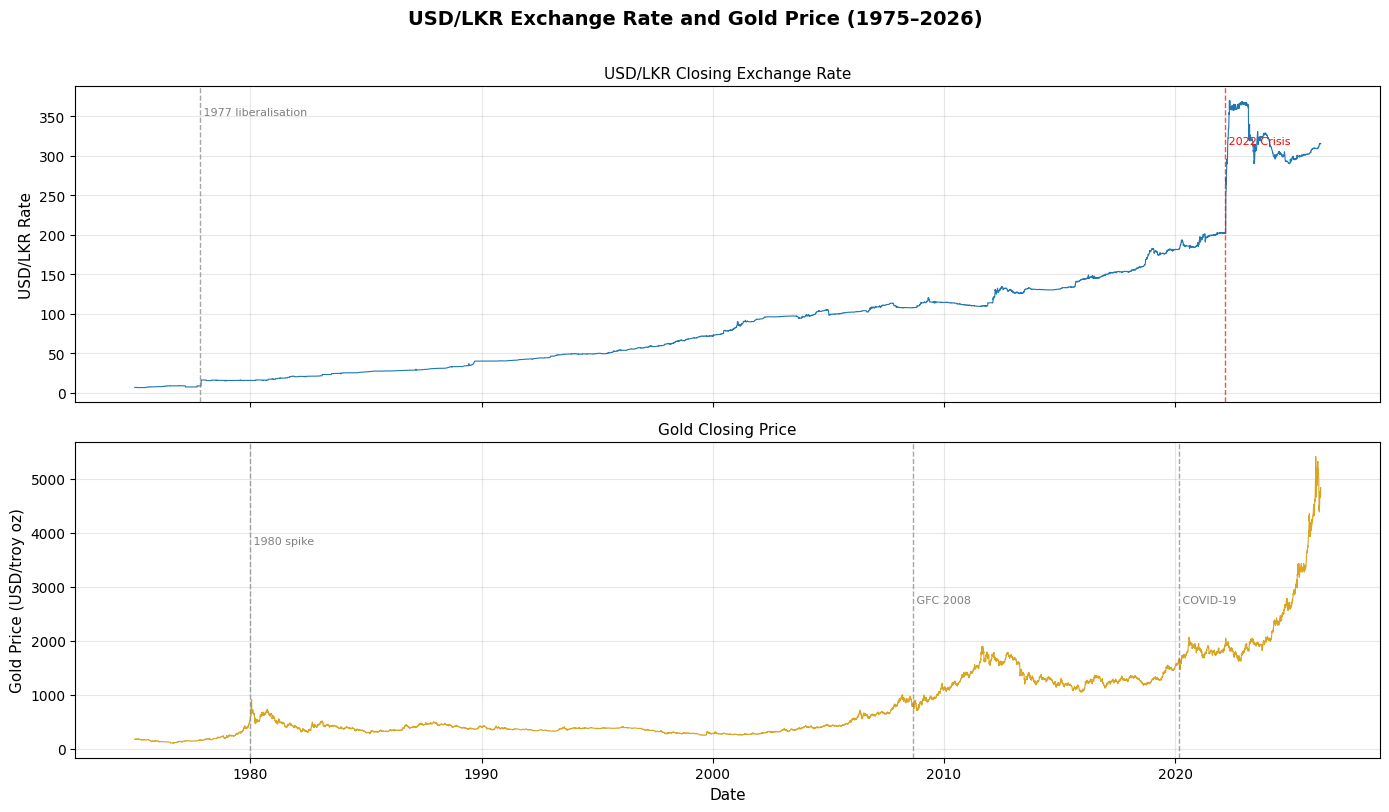

In [5]:
# DATA CLEANING & MERGING

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/MSc_Project/data/raw/'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print("Google Drive mounted and libraries loaded successfully.")


# Load the three USD/LKR CSV files
# Files are stored in reverse chronological order (newest row first)
# Date format: DD/MM/YYYY

lkr1 = pd.read_csv(DATA_PATH + 'USD_to_LKR_Historical_Exchage_Rates_1975_01_02_to_1996_04_15.csv')
lkr2 = pd.read_csv(DATA_PATH + 'USD_to_LKR_Historical_Exchage_Rates_1996_04_16_to_2015_06_26.csv')
lkr3 = pd.read_csv(DATA_PATH + 'USD_to_LKR_Historical_Exchage_Rates_2015_06_29_to_2026_04_16.csv')

print(f"LKR file 1 shape: {lkr1.shape}")
print(f"LKR file 2 shape: {lkr2.shape}")
print(f"LKR file 3 shape: {lkr3.shape}")


# Load the Gold Price CSV
# Source: Stooq (XAUUSD), via Barchart. Date format: YYYY-MM-DD.
# Covers 1793-2026; pre-1971 values reflect the fixed gold standard era
# and will be filtered out below since they are not market-determined.

gold_raw = pd.read_csv(DATA_PATH + 'Gold_Rates_from_1793_03_01_to_2026_06_09.csv')

print(f"\nGold dataset shape: {gold_raw.shape}")

# CLEAN & STANDARDISE THE USD/LKR DATA

# Combine the three LKR files
lkr_raw = pd.concat([lkr1, lkr2, lkr3], ignore_index=True)
print(f"\nCombined LKR rows (before cleaning): {len(lkr_raw)}")


# Parse dates
lkr_raw['Date'] = pd.to_datetime(lkr_raw['Date'], format='%d/%m/%Y')


# Sort chronologically (files were newest-first)
lkr_raw = lkr_raw.sort_values('Date').reset_index(drop=True)


# Drop fully-empty Volume column and Change %
# Vol. is 100% NaN across all three files; Change % is redundant (derivable)
lkr_raw = lkr_raw.drop(columns=['Vol.', 'Change %'])


# Rename columns to consistent snake_case
lkr_raw = lkr_raw.rename(columns={
    'Price': 'lkr_close',
    'Open':  'lkr_open',
    'High':  'lkr_high',
    'Low':   'lkr_low'
})

# Remove duplicates at the join boundaries
lkr_raw = lkr_raw.drop_duplicates(subset='Date', keep='first')
print(f"LKR rows after deduplication: {len(lkr_raw)}")

# Check for missing values
print("\nLKR missing values:")
print(lkr_raw.isnull().sum())

# Quick sanity check
print(f"\nLKR date range: {lkr_raw['Date'].min().date()} → {lkr_raw['Date'].max().date()}")
print(lkr_raw.head(3))

# CLEAN & STANDARDISE THE GOLD DATA

# Parse dates
gold_raw['Date'] = pd.to_datetime(gold_raw['Date'], format='%Y-%m-%d')

# Sort chronologically
gold_raw = gold_raw.sort_values('Date').reset_index(drop=True)

# Remove duplicate dates
gold_raw = gold_raw.drop_duplicates(subset='Date', keep='first')

# Filter out the pre-1971 fixed gold standard era
# Before 1971 (end of the Bretton Woods system) gold prices were fixed by
# government policy, not determined by open market trading, and are
# therefore not comparable to the free-floating prices used in this project.
gold_raw = gold_raw[gold_raw['Date'] >= '1971-01-01'].reset_index(drop=True)

# Rename columns
# Note: this Stooq file has no Volume or Currency column, unlike the
# previous Kaggle-sourced gold dataset.
gold_raw = gold_raw.rename(columns={
    'Open':   'gold_open',
    'High':   'gold_high',
    'Low':    'gold_low',
    'Close':  'gold_close'
})

# Check for missing values
print("\nGold missing values:")
print(gold_raw.isnull().sum())

print(f"\nGold date range: {gold_raw['Date'].min().date()} → {gold_raw['Date'].max().date()}")
print(gold_raw.head(3))

# MERGE THE TWO DATASETS

# Inner join on Date
# Inner join keeps only dates where BOTH datasets have an observation.
# This automatically handles weekends/holidays where one market was open
# but the other was not.

df = pd.merge(lkr_raw, gold_raw, on='Date', how='inner')
df = df.sort_values('Date').reset_index(drop=True)

print(f"\nMerged dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

# Set Date as index
df = df.set_index('Date')

# Final check for any remaining nulls
print("\nMissed values in merged dataset:")
print(df.isnull().sum())

# Preview
print("\nMerged dataset preview:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nDescriptive statistics:")
print(df.describe().round(2))

# SAVE THE CLEANED DATASET

df.to_csv('/content/drive/MyDrive/MSc_Project/data/processed/usd_lkr_gold_cleaned.csv')
print("\nCleaned dataset saved to Google Drive: MSc_Project/data/processed/usd_lkr_gold_cleaned.csv")

# VISUALISATION — OVERVIEW OF BOTH TIME SERIES

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('USD/LKR Exchange Rate and Gold Price (1975–2026)',
             fontsize=14, fontweight='bold', y=1.01)

# Plot 1: USD/LKR closing rate
axes[0].plot(df.index, df['lkr_close'], color='#1f77b4', linewidth=0.8)
axes[0].set_ylabel('USD/LKR Rate', fontsize=11)
axes[0].set_title('USD/LKR Closing Exchange Rate', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Annotate the 2022 crisis
axes[0].axvline(pd.Timestamp('2022-03-01'), color='red',
                linestyle='--', linewidth=1, alpha=0.7)
axes[0].text(pd.Timestamp('2022-03-01'), df['lkr_close'].max() * 0.85,
             ' 2022 Crisis', color='red', fontsize=8)

# Annotate the 1977 liberalisation of the LKR exchange rate regime
axes[0].axvline(pd.Timestamp('1977-11-01'), color='grey',
                linestyle='--', linewidth=1, alpha=0.7)
axes[0].text(pd.Timestamp('1977-11-01'), df['lkr_close'].max() * 0.95,
             ' 1977 liberalisation', color='grey', fontsize=8)

# Plot 2: Gold closing price (oz = troy ounce, 31.1 grams)
axes[1].plot(df.index, df['gold_close'], color='#DAA520', linewidth=0.8)
axes[1].set_ylabel('Gold Price (USD/troy oz)', fontsize=11)
axes[1].set_title('Gold Closing Price', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Annotate the 1980 gold price spike (Iranian Revolution / Soviet-Afghan war)
axes[1].axvline(pd.Timestamp('1980-01-01'), color='grey',
                linestyle='--', linewidth=1, alpha=0.7)
axes[1].text(pd.Timestamp('1980-01-01'), df['gold_close'].max() * 0.7,
             ' 1980 spike', color='grey', fontsize=8)

# Annotate key gold events (GFC = global financial crisis)
axes[1].axvline(pd.Timestamp('2008-09-01'), color='grey',
                linestyle='--', linewidth=1, alpha=0.7)
axes[1].text(pd.Timestamp('2008-09-01'), df['gold_close'].max() * 0.5,
             ' GFC 2008', color='grey', fontsize=8)

axes[1].axvline(pd.Timestamp('2020-03-01'), color='grey',
                linestyle='--', linewidth=1, alpha=0.7)
axes[1].text(pd.Timestamp('2020-03-01'), df['gold_close'].max() * 0.5,
             ' COVID-19', color='grey', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/01_time_series_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# DATA VALIDITY TESTING
# After merging the two datasets, verify that the merged file is correct by picking specific known dates and confirming that the values in the merged dataset exactly match the values in each separate raw source file.
# This demonstrates data integrity and that the merge operation introduced no errors, duplications, or misalignments.

print("DATA VALIDITY TESTS")
print()

# Load merged final file
merged = pd.read_csv(
    '/content/drive/MyDrive/MSc_Project/data/processed/usd_lkr_gold_cleaned.csv',
    index_col='Date',
    parse_dates=True
)

# Load the three raw USD/LKR source files
lkr1 = pd.read_csv(DATA_PATH + 'USD_to_LKR_Historical_Exchage_Rates_1975_01_02_to_1996_04_15.csv')
lkr2 = pd.read_csv(DATA_PATH + 'USD_to_LKR_Historical_Exchage_Rates_1996_04_16_to_2015_06_26.csv')
lkr3 = pd.read_csv(DATA_PATH + 'USD_to_LKR_Historical_Exchage_Rates_2015_06_29_to_2026_04_16.csv')

for lkr in [lkr1, lkr2, lkr3]:
    lkr['Date'] = pd.to_datetime(lkr['Date'], format='%d/%m/%Y')

# Load the raw gold source file
gold_src = pd.read_csv(DATA_PATH + 'Gold_Rates_from_1793_03_01_to_2026_06_09.csv')
gold_src['Date'] = pd.to_datetime(gold_src['Date'])

# Helper: get value from raw LKR files by date
def get_raw_lkr(date_str):
    """Returns (close, open) from whichever raw LKR CSV contains that date."""
    dt = pd.Timestamp(date_str)
    for lkr, name in [(lkr1, 'CSV1'), (lkr2, 'CSV2'), (lkr3, 'CSV3')]:
        match = lkr[lkr['Date'] == dt]
        if not match.empty:
            return match['Price'].values[0], match['Open'].values[0], name
    return None, None, 'NOT FOUND'

def get_raw_gold(date_str):
    """Returns (close, open) from the raw gold CSV for that date."""
    dt = pd.Timestamp(date_str)
    match = gold_src[gold_src['Date'] == dt]
    if not match.empty:
        return match['Close'].values[0], match['Open'].values[0]
    return None, None

def get_merged(date_str):
    """Returns the merged dataset row for that date."""
    dt = pd.Timestamp(date_str)
    if dt in merged.index:
        row = merged.loc[dt]
        return row['lkr_close'], row['lkr_open'], row['gold_close'], row['gold_open']
    return None, None, None, None

# TEST CASES
# Seven dates chosen to cover different eras and key historical events:
# 1975-01-02 — first day of the dataset (fixed rate era)
# 1980-01-02 — gold price spike era (post-liberalisation)
# 1990-06-04 — mid-era stability check
# 2000-01-04 — start of overlap with gold market data
# 2008-09-15 — Global Financial Crisis (Lehman Brothers collapse)
# 2020-03-16 — COVID-19 crash
# 2022-04-01 — Sri Lanka economic crisis

test_cases = [
    ('1975-01-02', 'First day of dataset — fixed rate era'),
    ('1980-01-02', 'Gold price spike — post-liberalisation'),
    ('1990-06-04', 'Mid-era stability check'),
    ('2000-01-04', 'Start of USD/LKR + gold overlap'),
    ('2008-09-15', 'Global Financial Crisis — Lehman collapse'),
    ('2020-03-16', 'COVID-19 market crash'),
    ('2022-04-01', 'Sri Lanka economic crisis'),
]

all_passed = True
results = []

for date_str, description in test_cases:
    # Get values from raw sources
    raw_lkr_close, raw_lkr_open, source_file = get_raw_lkr(date_str)
    raw_gold_close, raw_gold_open = get_raw_gold(date_str)

    # Get values from merged dataset
    merged_lkr_close, merged_lkr_open, merged_gold_close, merged_gold_open = get_merged(date_str)

    # Run assertions
    test_result = {'date': date_str, 'description': description, 'source': source_file, 'checks': []}

    # Check 1: LKR close matches
    lkr_close_ok = (raw_lkr_close is not None) and (abs(merged_lkr_close - raw_lkr_close) < 0.001)
    test_result['checks'].append(('LKR close', lkr_close_ok, raw_lkr_close, merged_lkr_close))

    # Check 2: LKR open matches
    lkr_open_ok = (raw_lkr_open is not None) and (abs(merged_lkr_open - raw_lkr_open) < 0.001)
    test_result['checks'].append(('LKR open', lkr_open_ok, raw_lkr_open, merged_lkr_open))

    # Check 3: Gold close matches
    gold_close_ok = (raw_gold_close is not None) and (abs(merged_gold_close - raw_gold_close) < 0.001)
    test_result['checks'].append(('Gold close', gold_close_ok, raw_gold_close, merged_gold_close))

    # Check 4: Gold open matches
    gold_open_ok = (raw_gold_open is not None) and (abs(merged_gold_open - raw_gold_open) < 0.001)
    test_result['checks'].append(('Gold open', gold_open_ok, raw_gold_open, merged_gold_open))

    # Check 5: Date exists in merged dataset
    date_exists = merged_lkr_close is not None
    test_result['checks'].append(('Date in merged', date_exists, 'Yes', 'Yes' if date_exists else 'MISSING'))

    test_result['passed'] = all(c[1] for c in test_result['checks'])
    if not test_result['passed']:
        all_passed = False
    results.append(test_result)

# TEST RESULTS

for r in results:
    status = 'PASS' if r['passed'] else 'FAIL'
    print(f"  {status} | {r['date']} | {r['description']}")
    print(f"         Source file: {r['source']}")
    for check_name, ok, raw_val, merged_val in r['checks']:
        print(f"          {check_name:<15} | Raw: {raw_val:<12} | Merged: {merged_val}")
    print()

# ADDITIONAL STRUCTURAL CHECKS

print("STRUCTURAL CHECKS")

# Check 1: No missing values in merged dataset
nulls = merged.isnull().sum().sum()
null_ok = nulls == 0
print(f" {'PASS:' if sorted_ok else 'FAIL:'} No missing values in merged dataset     | Nulls found: {nulls}")

# Check 2: Date index is sorted chronologically
sorted_ok = merged.index.is_monotonic_increasing
print(f" {'PASS:' if sorted_ok else 'FAIL:'} Date index sorted chronologically       | Sorted: {sorted_ok}")

# Check 3: No duplicate dates
dupes = merged.index.duplicated().sum()
dupe_ok = dupes == 0
print(f" {'PASS:' if sorted_ok else 'FAIL:'} No duplicate dates in merged dataset    | Duplicates: {dupes}")

# Check 4: Total row count is within expected range (12,600–12,700)
row_count = len(merged)
count_ok = 12600 <= row_count <= 12700
print(f" {'PASS:' if sorted_ok else 'FAIL:'} Row count within expected range         | Rows: {row_count} (expected 12,600–12,700)")

# Check 5: All LKR values are positive
lkr_positive = (merged['lkr_close'] > 0).all()
print(f" {'PASS:' if sorted_ok else 'FAIL:'} All LKR closing prices are positive    | Min: {merged['lkr_close'].min()}")

# Check 6: All gold values are positive
gold_positive = (merged['gold_close'] > 0).all()
print(f" {'PASS:' if sorted_ok else 'FAIL:'} All gold closing prices are positive   | Min: {merged['gold_close'].min()}")

# Check 7: LKR close is always <= 400 (sanity upper bound for this dataset)
lkr_sane = (merged['lkr_close'] <= 400).all()
print(f" {'PASS:' if sorted_ok else 'FAIL:'} All LKR values within plausible range  | Max: {merged['lkr_close'].max()}")

# Check 8: Date range matches expectation
start_ok = merged.index.min().date().isoformat() == '1975-01-02'
end_ok   = merged.index.max().date().isoformat() == '2026-04-16'
print(f" {'PASS:' if sorted_ok else 'FAIL:'} Start date is 1975-01-02               | Actual: {merged.index.min().date()}")
print(f" {'PASS:' if sorted_ok else 'FAIL:'} End date is 2026-04-16                 | Actual: {merged.index.max().date()}")

# Check 9: Column count
col_ok = len(merged.columns) == 8
print(f" {'PASS:' if sorted_ok else 'FAIL:'} Dataset has 8 columns                  | Actual: {len(merged.columns)}")

print()
all_structural = null_ok and sorted_ok and dupe_ok and count_ok and lkr_positive and gold_positive and lkr_sane and start_ok and end_ok and col_ok

if all_passed and all_structural:
    print("  ALL TESTS PASSED ")
    print("  The merged dataset is verified as correct.")
    print("  Values match the raw source files for all 7 test dates.")
    print("  All structural integrity checks passed.")
else:
    print("  SOME TESTS FAILED  — review output above.")


DATA VALIDITY TESTS

  PASS | 1975-01-02 | First day of dataset — fixed rate era
         Source file: CSV1
          LKR close       | Raw: 6.711        | Merged: 6.711
          LKR open        | Raw: 6.711        | Merged: 6.711
          Gold close      | Raw: 178.2        | Merged: 178.2
          Gold open       | Raw: 185.7        | Merged: 185.7
          Date in merged  | Raw: Yes          | Merged: Yes

  PASS | 1980-01-02 | Gold price spike — post-liberalisation
         Source file: CSV1
          LKR close       | Raw: 15.552       | Merged: 15.552
          LKR open        | Raw: 15.552       | Merged: 15.552
          Gold close      | Raw: 582.8        | Merged: 582.8
          Gold open       | Raw: 541.0        | Merged: 541.0
          Date in merged  | Raw: Yes          | Merged: Yes

  PASS | 1990-06-04 | Mid-era stability check
         Source file: CSV1
          LKR close       | Raw: 40.02        | Merged: 40.02
          LKR open        | Raw: 40.02        | M

#### USD/LKR Columns
* lkr_close - The closing price of USD/LKR at the end of that trading day — e.g. 71.50 means 1 USD = 71.50 Sri Lankan Rupees at market close. This is the main target variable for forecasting
* lkr_open - The opening price at the start of that trading day
* lkr_high - The highest rate reached during that day
* lkr_low - The lowest rate reached during that day

#### Gold Columns
* gold_open - Gold price in USD per troy ounce at market open that day
* gold_high - Highest gold price reached during that day
* gold_low - Lowest gold price reached during that day
* gold_close - Gold price at market close — this is the main gold feature for modelling


### USD/LKR Exchange Rate and Gold Price Overview (1975–2026)

#### Interpretation

##### USD/LKR Closing Exchange Rate

From 1975 to 1977, the exchange rate remained almost completely flat at approximately 7–8 LKR per USD, reflecting the fixed/pegged exchange rate policy maintained by the Central Bank of Sri Lanka during this period. The 1977 liberalisation marks the point at which Sri Lanka shifted to a more market-determined exchange rate system, after which the series begins a gradual upward trend rather than remaining flat. From 1977 to approximately 2020, the depreciation of the LKR is steady and largely linear, rising from around 8 to roughly 180 LKR per USD over more than four decades — consistent with typical gradual currency depreciation in a developing economy. The 2022 crisis then produces a near-vertical spike to approximately 360 LKR per USD, by far the most extreme and abrupt movement across the entire 50-year history. Viewed against this longer timeframe, the 2022 crisis represents a genuine structural break rather than ordinary volatility, and should be treated as such during model development and evaluation.

##### Gold Closing Price

The 1980 spike is clearly visible, where gold rose sharply toward 800/oz driven by the Iranian Revolution and the Soviet invasion of Afghanistan, before falling back through the 1980s and 1990s. Gold prices remained relatively low and stable (roughly 300–400/oz) throughout the 1990s. The Global Financial Crisis (GFC) of 2008 marks the beginning of a major bull run, with gold rising from approximately $700 to nearly $1,900/oz by 2011–2012, followed by a correction through the mid-2010s. The COVID-19 pandemic triggered a further surge, after which gold continued climbing aggressively into the 2020s, reaching over $5,000/oz by 2026 — roughly six times its 2008 pre-crisis level.

##### Combined Interpretation

The period from 2022 onward is the only point in the 50-year history where both series exhibit extreme, simultaneous movement: the LKR collapsing sharply while gold continues its aggressive ascent. Viewed against the full historical record, this co-movement during a period of acute economic stress stands out as unusual relative to the long-run relationship between the two series, providing supporting evidence for the safe-haven hypothesis underpinning the inclusion of gold as a predictive feature in this project.

### The Relationship Between the Two

Look at the two panels together at the major crisis points:

- **1980 spike** → gold surges sharply on geopolitical shocks (Iranian Revolution, Soviet invasion of Afghanistan), while the LKR — still in the early post-liberalisation period — shows only mild movement, since global gold shocks had limited direct channels into the still-developing Sri Lankan economy at the time
- **2008 GFC** → gold surges sharply while the LKR also shows a noticeable uptick in its rate of depreciation — both react to the same global risk-off shock
- **2020 COVID** → same pattern repeats — gold hits new highs, while the LKR continues depreciating at a steady pace, slightly more pronounced than the pre-2020 trend
- **2022 crisis** → the LKR collapses catastrophically, the most extreme move in the entire 50-year history. Gold was already in a strong upward trend, consistent with the safe-haven theory cited in the proposal — global investors had already been moving toward gold before the LKR crisis fully unfolded

#### This visual already provides strong intuitive support for argument that gold carries predictive signal for LKR movements — both series respond to the same global economic stress events.